Adaline for IRIS dataset

Preprocessing

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
iris=datasets.load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
df_selected=df[~(df['target']==2)]
df_selected=df_selected.drop(['sepal length (cm)','sepal width (cm)'],axis=1)
df_selected.sample(10)

,petal length (cm),petal width (cm),target
80,3.8,1.1,1
6,1.4,0.3,0
14,1.2,0.2,0
27,1.5,0.2,0
45,1.4,0.3,0
58,4.6,1.3,1
44,1.9,0.4,0
13,1.1,0.1,0
74,4.3,1.3,1
24,1.9,0.2,0


In [3]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
original_columns=df_selected.columns
df_selected=pd.DataFrame(scaler.fit_transform(df_selected),columns=original_columns)
df_selected.head()

,petal length (cm),petal width (cm),target
0,0.097561,0.058824,0.0
1,0.097561,0.058824,0.0
2,0.073171,0.058824,0.0
3,0.121951,0.058824,0.0
4,0.097561,0.058824,0.0


In [4]:
from sklearn.model_selection import train_test_split
target_column='target'
x=df_selected.drop(target_column,axis=1)
y=df_selected[[target_column]]
y=np.where(y==0,-1,1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,stratify=df_selected[target_column], random_state=42)

Train the Adaline model

In [5]:
class Adaline:
    def __init__(self,Input=2,learning_rate=0.1, epochs=50):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.weights=np.random.rand(Input)
        self.bias=np.random.rand(1)
    def fit(self,x,y):
        self.costs_=[]
        self.accuracy_=[]

        for _ in range(self.epochs):
            output=self.net_input(x)
            error=y.ravel()-output
            self.weights +=self.learning_rate* x.T.dot(error)
            self.bias +=self.learning_rate*error.sum()
            cost=(error**2).sum()/2
            self.costs_.append(cost)
            y_pred=self.predict(x)
            accuracy=np.mean(y_pred==y.ravel())
            self.accuracy_.append(accuracy)

    def net_input(self,x):
        return np.dot(x,self.weights)+self.bias

    def predict(self,x):
        return np.where(self.net_input(x)>=0.0,1,-1)

final weights: [1.90436345 1.45497936]
final bias: [-0.48997165]
cost: [np.float64(55.03406001189426), np.float64(46.401692287991494), np.float64(41.20533295830413), np.float64(38.105873267968875), np.float64(36.28625647980476), np.float64(35.24795666991985), np.float64(34.686799968448035), np.float64(34.417196708766625), np.float64(34.325911563048614), np.float64(34.34385632320721)]
accuracy: [np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5428571428571428), np.float64(0.5), np.float64(0.8714285714285714), np.float64(0.5285714285714286), np.float64(0.9), np.float64(0.5571428571428572), np.float64(0.9428571428571428)]


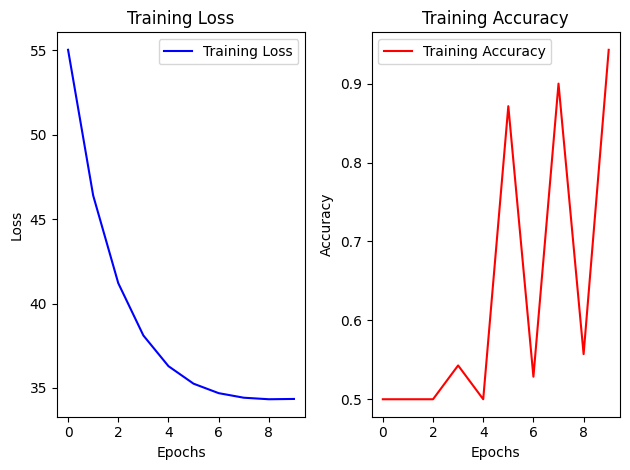

In [68]:
import matplotlib.pyplot as plt
Input=x.shape[1]
Output=1
learning_rate=0.02
epochs=10
model=Adaline(Input,learning_rate,epochs)
model.fit(np.array(x_train),y_train)
bias_1d = np.atleast_1d(model.bias)
weights1 = np.concatenate((bias_1d, model.weights))
print("final weights:", model.weights)
print("final bias:", model.bias)
print("cost:", model.costs_)
print("accuracy:", model.accuracy_)
plt.subplot(1, 2, 1)
plt.plot(model.costs_, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model.accuracy_, 'r', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

final weights: [0.87582359 0.58722345]
final bias: [-0.51590672]
cost: [np.float64(81.66297539550278), np.float64(38.73875644007871), np.float64(26.23372309196234), np.float64(21.503446697981428), np.float64(18.882893427127073), np.float64(16.941662227934046), np.float64(15.306864936378467), np.float64(13.87095818452871), np.float64(12.59409453082869), np.float64(11.454689154669358)]
accuracy: [np.float64(0.5), np.float64(0.5), np.float64(0.5571428571428572), np.float64(0.9857142857142858), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


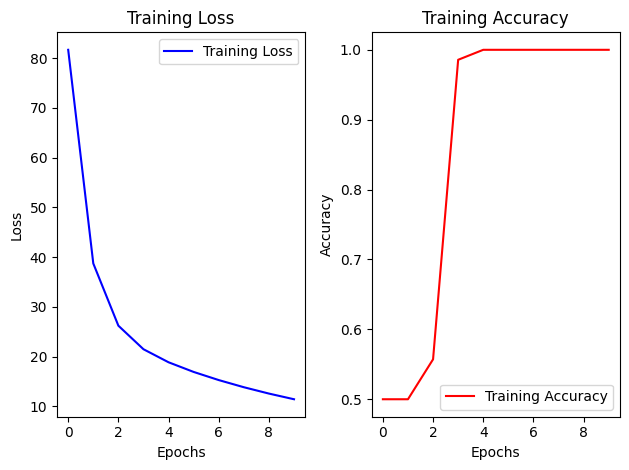

In [69]:
learning_rate=0.005
model=Adaline(Input,learning_rate,epochs)
model.fit(np.array(x_train),y_train)
bias_1d = np.atleast_1d(model.bias)
weights2 = np.concatenate((bias_1d, model.weights))
print("final weights:", model.weights)
print("final bias:", model.bias)
print("cost:", model.costs_)
print("accuracy:", model.accuracy_)
plt.subplot(1, 2, 1)
plt.plot(model.costs_, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model.accuracy_, 'r', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

final weights: [0.27248569 0.54893   ]
final bias: [0.25362362]
cost: [np.float64(81.67552474220123), np.float64(71.42750325233312), np.float64(63.022139909861735), np.float64(56.111177753353815), np.float64(50.412569436945276), np.float64(45.6978810999021), np.float64(41.782092788857625), np.float64(38.51533945810583), np.float64(35.776223328388205), np.float64(33.46639863339774)]
accuracy: [np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5)]


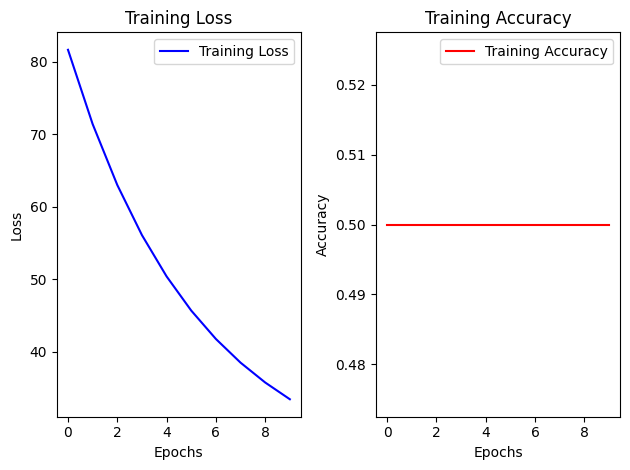

In [70]:
learning_rate=0.001
model=Adaline(Input,learning_rate,epochs)
model.fit(np.array(x_train),y_train)
bias_1d = np.atleast_1d(model.bias)
weights3 = np.concatenate((bias_1d, model.weights))
print("final weights:", model.weights)
print("final bias:", model.bias)
print("cost:", model.costs_)
print("accuracy:", model.accuracy_)
plt.subplot(1, 2, 1)
plt.plot(model.costs_, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model.accuracy_, 'r', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

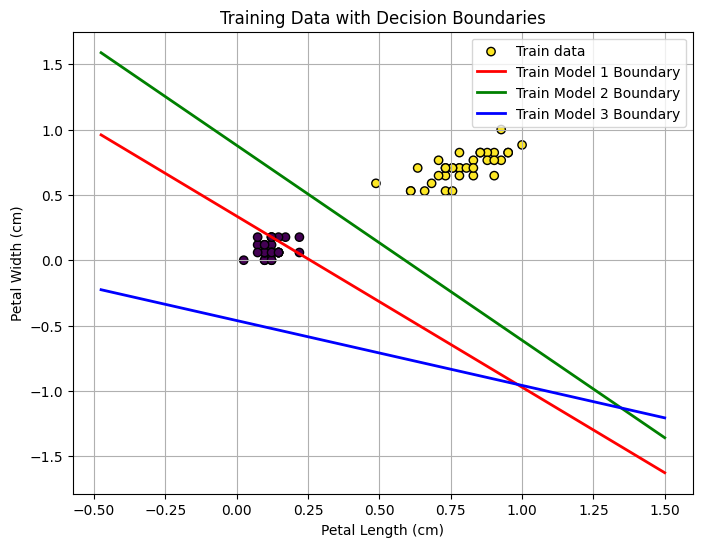

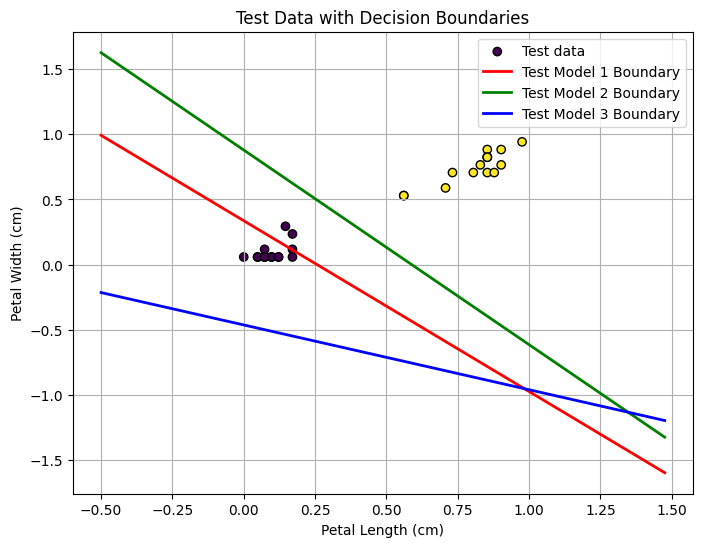

In [71]:
weights_train = [np.array(weights1),np.array(weights2),np.array(weights3)]
weights_test = [np.array(weights1),np.array(weights2),np.array(weights3)]
plt.figure(figsize=(8, 6))
plt.scatter(x_train.iloc[:,0],x_train.iloc[:,1],
            c=y_train.ravel(),cmap='viridis',marker='o',edgecolor='k',label='Train data')
x_vals = np.linspace(x_train.iloc[:,0].min()-0.5,x_train.iloc[:,0].max()+0.5,100)
colors = ['r-','g-','b-']
for i,weights in enumerate(weights_train):
    y_line =-(weights[1]/weights[2])*x_vals-(weights[0]/weights[2])
    plt.plot(x_vals,y_line,colors[i],linewidth=2,label=f'Train Model {i+1} Boundary')

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Training Data with Decision Boundaries")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(x_test.iloc[:,0],x_test.iloc[:,1],
            c=y_test.ravel(),cmap='viridis',marker='o',edgecolor='k',label='Test data')
x_vals_test = np.linspace(x_test.iloc[:,0].min()-0.5,x_test.iloc[:,0].max()+0.5,100)

for i, weights in enumerate(weights_test):
    y_line_test=-(weights[1]/weights[2])*x_vals_test-(weights[0]/weights[2])
    plt.plot(x_vals_test,y_line_test,colors[i],linewidth=2,label=f'Test Model {i+1} Boundary')

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Test Data with Decision Boundaries")
plt.legend()
plt.grid(True)
plt.show()